# Objectif du notebook 

Date de création : 03/05/2026

L'objectif est de tester la sensibilité de l'estimateur CS-EVD aux paramètres de calcul de la matrice de covariance. 

Le couple de paramètres optimaux est choisi par comparaison avec l'estimation par déconvolution. 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

# Étape 1 : sélection d'une sous partie de la séquence

L'étude de sensibilité est menée pour l'émission au CPA de l'OBS 2 de référence. Ce choix permet d'avoir des performances équivalentes pour les deux rapports 1/2 et 3/2 (Cf notebook cs_evd_vs_wiener.ipynb). 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 3.0,
    "alpha_overlap": 0.5,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

## Calcul des RTFs

In [6]:
###########################
# Run once 
###########################
id_library = 500

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )

In [7]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_500.nc"
ds = xr.open_dataset(fpath)
ds

dist_rcv = get_dist_to_rcv(ds)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds.replica_id.values

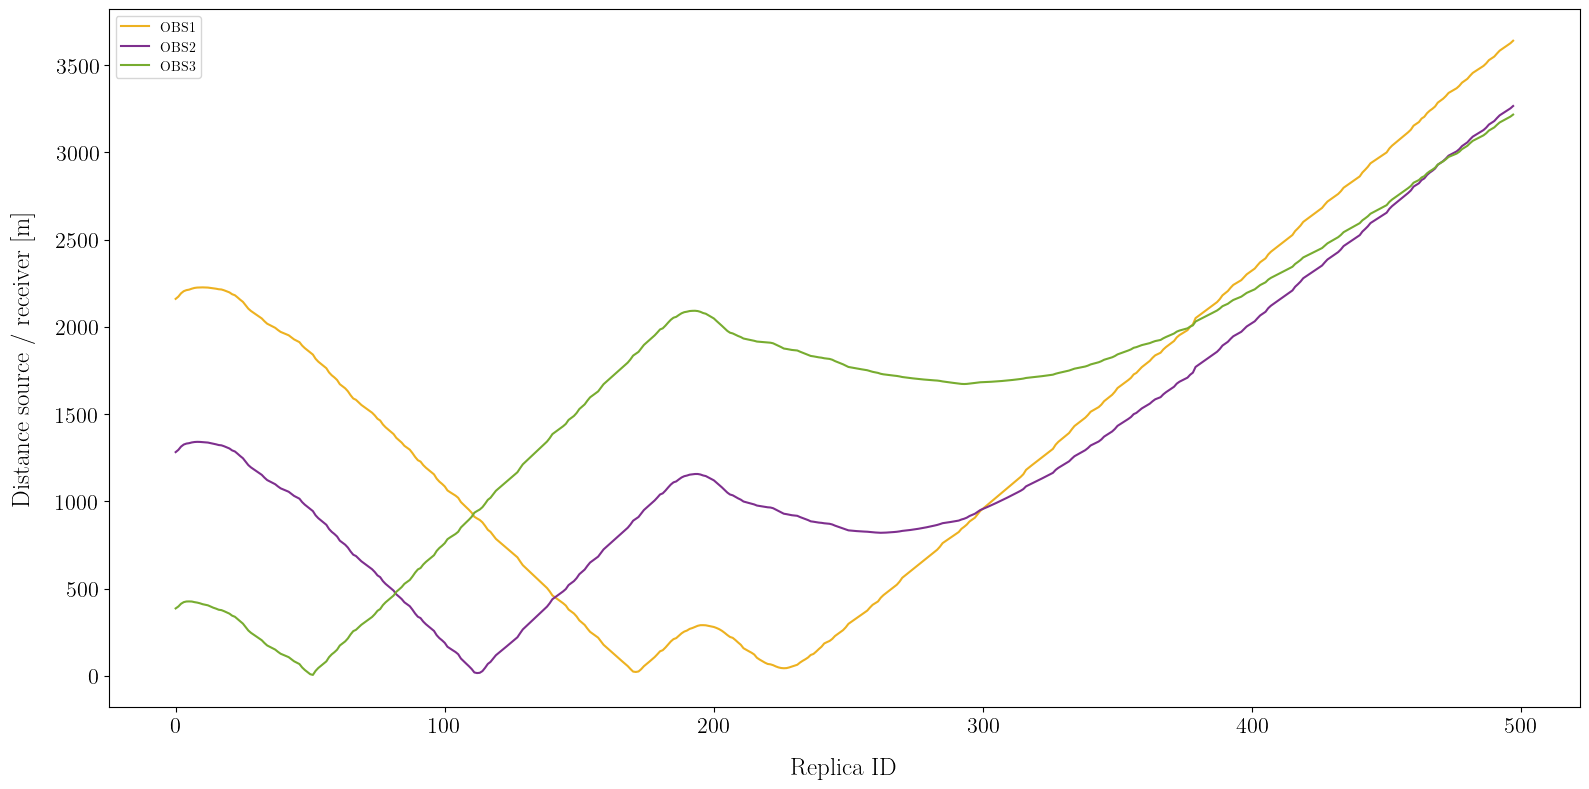

In [8]:
plt.figure()
for i_rcv in range(dist_rcv.shape[0]):
    plt.plot(reps, dist_rcv[i_rcv, :], label=f"OBS{i_rcv+1}", color=color(2 + i_rcv))
plt.xlabel("Replica ID")
plt.ylabel("Distance source / receiver [m]")
plt.legend()

In [9]:
fig_folder = os.path.join(sensibility_img_folder, "144", f"library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [10]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only cpa pulse
id_sel = np.argmin(np.abs(dist_rcv[0, :] - dist_rcv[1, :]))
pulse_slice = (id_sel-5, id_sel+5)
# pulse_slice = (
#     reps[obs_cpa_idx[1]],
#     reps[obs_cpa_idx[1]],
# )  # Only between OBS1 and OBS3
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [11]:
pulse_slice

(np.int64(136), np.int64(146))

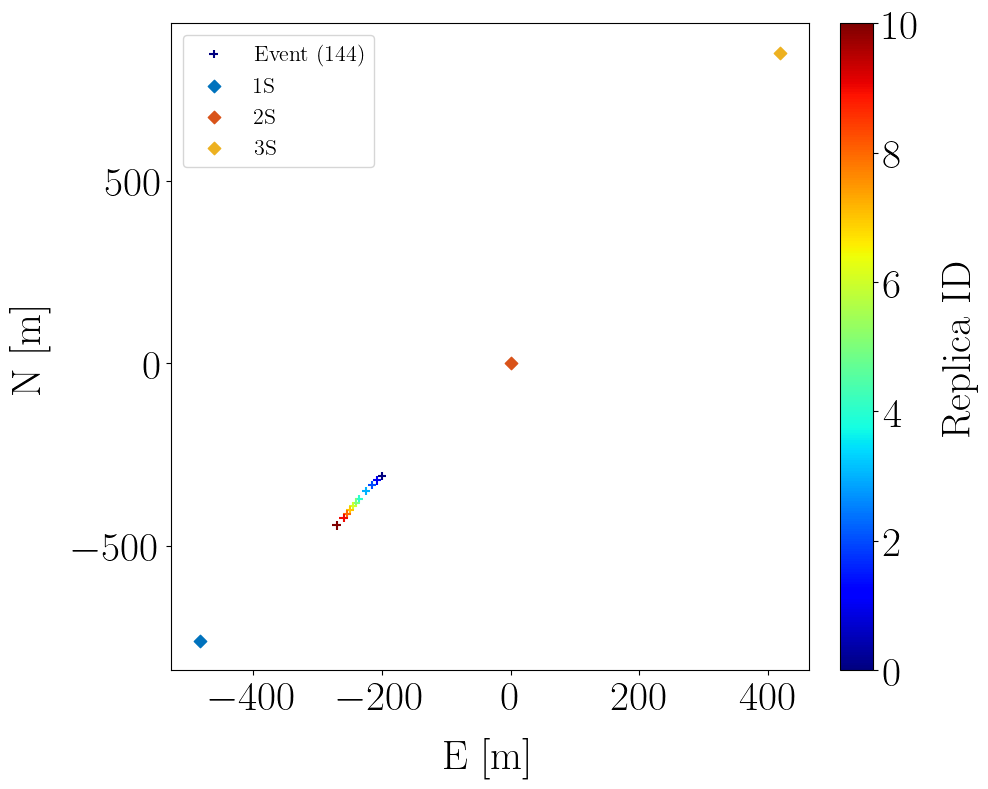

In [12]:
root_img_traj = os.path.join(fig_folder, "trajectory")
os.makedirs(root_img_traj, exist_ok=True)
plot_seq_replica_positions(df_seq, ds_gps, root_fig=root_img_traj)

## Étude de sensibilité 

In [13]:
active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}

In [14]:
# Set default params 
fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 3,
    "alpha_overlap": 0.5,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)



In [15]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

pulse_window_length_s = ds_sig.pulse_window_length_s
fs = ds_sig.fs

ds_sig.close()
del ds_sig

In [16]:
pulse_window_length_s

np.float32(10.04)

In [17]:
ids, params = run_sensibility_cs_evd(rtf_mfp_processor=rtf_mfp_processor, active_replicas_args=active_replicas_args, passive_replicas_args=passive_replicas_args, pulse_window_length_s=pulse_window_length_s, fs=fs)

n_perseg_min = 8, n_perseg_max = 14
ov_factor = [0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  0.95]
Initial params : 
	 nperseg = 4096 
	 noverlap = 2048

Deriving features for active source...

RTF processing of sequences [144] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 144
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 501 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_501.nc.
Updated params : 
	 nperseg = 256 
	 noverlap = 0
Progress: █...............................................

In [18]:
theta, theat_mod, d_L1, d_L1_mod = sensibility_cs_evd_analysis(
    library_ids=ids, fmin=400, fmax=800
)

In [19]:
theta.shape

(77, 11)

In [37]:
npersegs_p2 = np.unique([params[k][0] for k in range(len(params))])
alpha_ov = np.unique([params[k][1] for k in range(len(params))])

# L1
perc_L1 = np.percentile(d_L1, 50, axis=1)
perc_mat_L1 = perc_L1.reshape((npersegs_p2.size, alpha_ov.size))
# L1 mod
perc_L1_mod = np.percentile(d_L1_mod, 50, axis=1)
perc_mat_L1_mod = perc_L1_mod.reshape((npersegs_p2.size, alpha_ov.size))
# Theta
perc_theta = np.percentile(theta, 50, axis=1)
perc_mat_theta = perc_theta.reshape((npersegs_p2.size, alpha_ov.size))
# Theta mod
perc_theta_mod = np.percentile(theat_mod, 50, axis=1)
perc_mat_theta_mod = perc_theta_mod.reshape((npersegs_p2.size, alpha_ov.size))

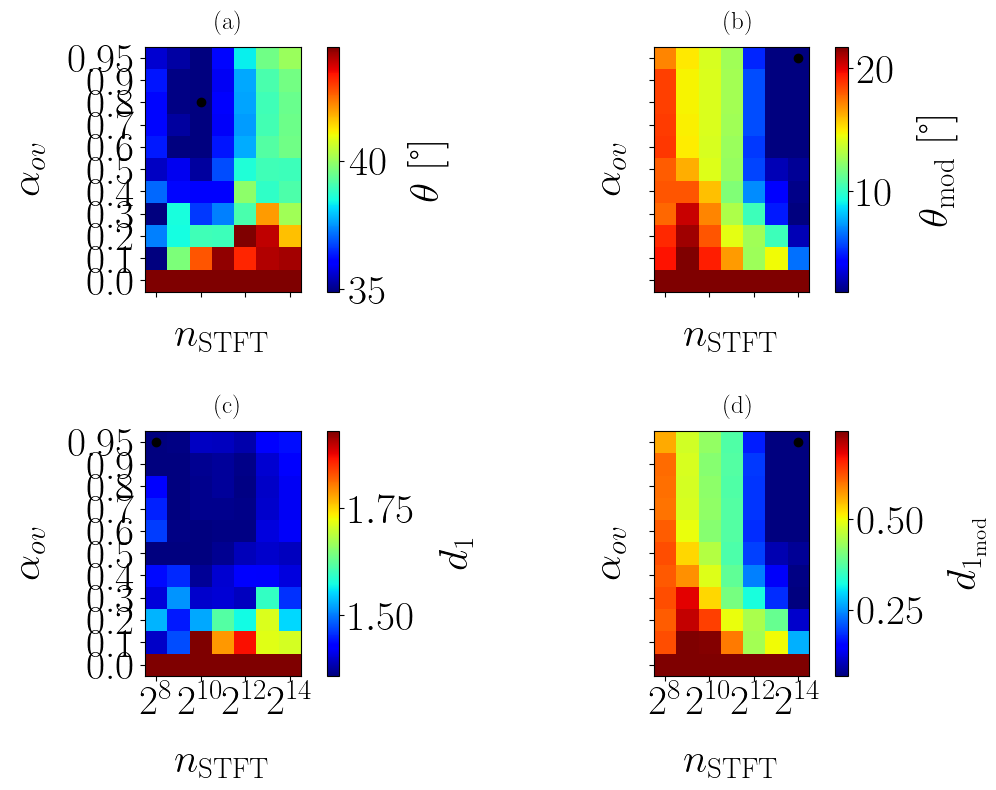

In [47]:
min_perc = 10
max_perc = 90
fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True, sharex=True)

# Theta
vmin = np.percentile(perc_mat_theta, min_perc)
vmax = np.percentile(perc_mat_theta, max_perc)
im = axs[0, 0].imshow(perc_mat_theta.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(ax=axs[0, 0], mappable=im, label=r"$\theta$ [°]", orientation="vertical")
ind = np.unravel_index(np.argmin(perc_mat_theta, axis=None), perc_mat_L1_mod.shape)
axs[0, 0].scatter(ind[0], ind[1], color="k")

# Theta mod
vmin = np.percentile(perc_mat_theta_mod, min_perc)
vmax = np.percentile(perc_mat_theta_mod, max_perc)
im = axs[0, 1].imshow(perc_mat_theta_mod.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(
    ax=axs[0, 1], mappable=im, label=r"$\theta_\text{mod}$ [°]", orientation="vertical"
)
ind = np.unravel_index(np.argmin(perc_mat_theta_mod, axis=None), perc_mat_L1_mod.shape)
axs[0, 1].scatter(ind[0], ind[1], color="k")

# L1
vmin = np.percentile(perc_mat_L1, min_perc)
vmax = np.percentile(perc_mat_L1, max_perc)
im = axs[1, 0].imshow(perc_mat_L1.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(
    ax=axs[1, 0], mappable=im, label=r"$d_1$", orientation="vertical"
)
ind = np.unravel_index(np.argmin(perc_mat_L1, axis=None), perc_mat_L1_mod.shape)
axs[1, 0].scatter(ind[0], ind[1], color="k")

# L1 mod
vmin = np.percentile(perc_mat_L1_mod, min_perc)
vmax = np.percentile(perc_mat_L1_mod, max_perc)
im = axs[1, 1].imshow(perc_mat_L1_mod.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(ax=axs[1, 1], mappable=im, label=r"$d_{1_\text{mod}}$", orientation="vertical")
ind = np.unravel_index(np.argmin(perc_mat_L1_mod, axis=None), perc_mat_L1_mod.shape)
axs[1, 1].scatter(ind[0], ind[1], color="k")

for ax in axs.flatten():
    ax.set_yticks(np.arange(len(alpha_ov)))
    ax.set_yticklabels(np.round(alpha_ov, 2))
    ax.set_xticks(np.arange(len(npersegs_p2))[::2])
    ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in npersegs_p2][::2])

    ax.set_ylabel(r"$\alpha_{ov}$")
    ax.set_xlabel(r"$n_{\textrm{STFT}}$")

set_subfigures_abc_labels(
    axs=axs,
    fontsize=18,
    x_pos=0.45,
    y_pos=1.15,
    ha="left",
    va="top",
)

fpath = os.path.join(fig_folder, "param_selection_4_distances.png")
plt.savefig(fpath, bbox_inches="tight")
# pl

In [22]:
# vmin = np.percentile(d_L1_mod, 5)
# vmax = np.percentile(d_L1_mod, 95)
# plt.figure()
# im = plt.pcolormesh(d_L1_mod, vmin=vmin, vmax=vmax, cmap="magma")
# plt.colorbar(im, label=r"L1 norm (mod)")

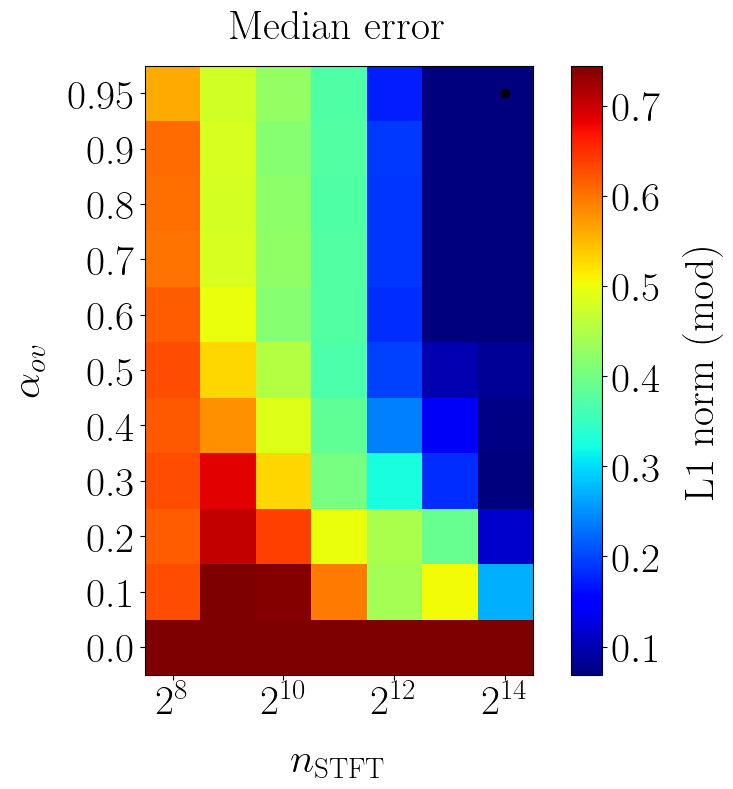

In [23]:
vmin = np.percentile(perc_mat_L1_mod, 10)
vmax = np.percentile(perc_mat_L1_mod, 90)

fig, ax = plt.subplots(nrows=1, ncols=1, sharey=True)

# ax = axs[0]
im = ax.imshow(perc_mat_L1_mod.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
ax.set_yticks(np.arange(len(alpha_ov)))
ax.set_yticklabels(np.round(alpha_ov, 2))
ax.set_xticks(np.arange(len(npersegs_p2))[::2])
ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in npersegs_p2][::2])

# ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
ax.set_ylabel(r"$\alpha_{ov}$")
ax.set_xlabel(r"$n_{\textrm{STFT}}$")
plt.colorbar(ax=ax, mappable=im, label=r"L1 norm (mod)", orientation="vertical")

ind = np.unravel_index(np.argmin(perc_mat_L1_mod, axis=None), perc_mat_L1_mod.shape)
ax.scatter(ind[0], ind[1], color="k")

plt.title("Median error")

fpath = os.path.join(fig_folder, "param_selection_L1_mod.png")
plt.savefig(fpath, bbox_inches="tight")
# pl

In [24]:
npersegs_p2_opti = npersegs_p2[ind[0]]
npersegs_opti = 2**npersegs_p2_opti

alpha_ov_opti = alpha_ov[ind[1]]

print(f"nperseg_opti = {npersegs_opti}, alpha_ov_opti = {alpha_ov_opti}")
tau_stft = npersegs_opti * 1 / fs
print(f"tau_stft_opti = {tau_stft}s")

nperseg_opti = 16384, alpha_ov_opti = 0.95
tau_stft_opti = 8.192s


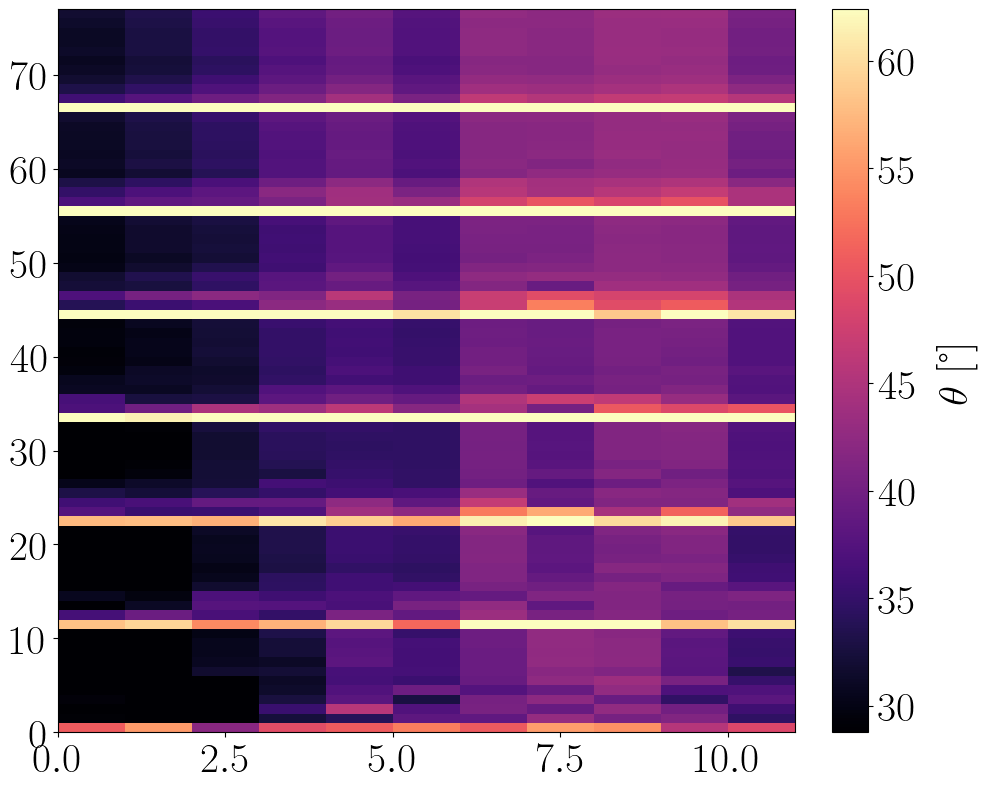

In [25]:
vmin = np.percentile(theta, 5)
vmax = np.percentile(theta, 95)
plt.figure()
im = plt.pcolormesh(theta, vmin=vmin, vmax=vmax, cmap="magma")
plt.colorbar(im, label=r"$\theta$ [°]")

# plt.figure()
# for i_param_set in range(len(params)):
#     plt.plot(theta[i_param_set], label=f"{params[i_param_set]}")
# plt.legend(fontsize=10)

In [26]:
perc = np.percentile(theta, 50, axis=1)
# perc = np.min(theta, axis=1)
npersegs_p2 = np.unique([params[k][0] for k in range(len(params))])
alpha_ov = np.unique([params[k][1] for k in range(len(params))])
perc_mat_theta = perc.reshape((npersegs_p2.size, alpha_ov.size))

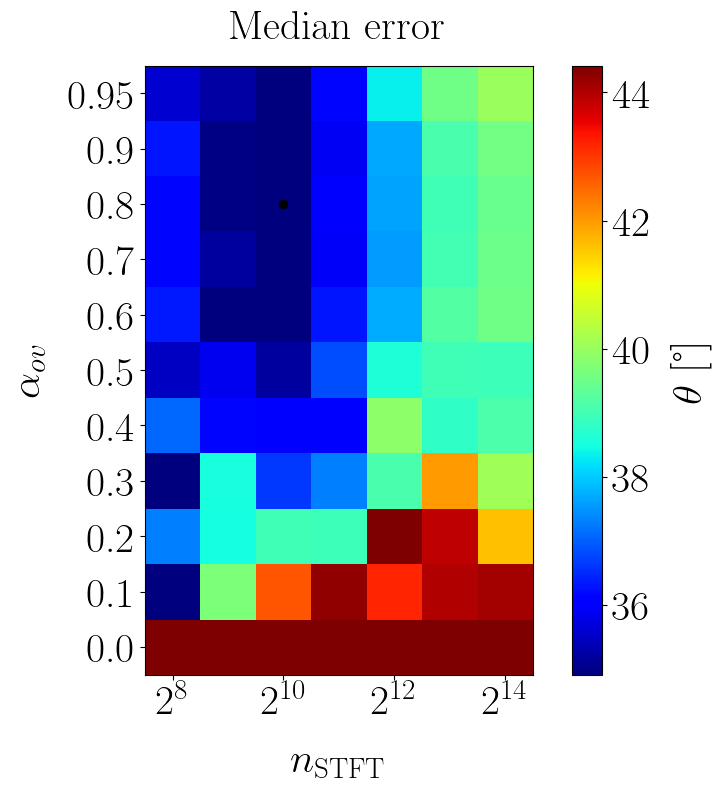

In [27]:
vmin = np.percentile(perc_mat_theta, 10)
vmax = np.percentile(perc_mat_theta, 90)

# vmin = np.min(perc_mat)
# vmax = np.max(perc_mat)

# plt.figure()
# im = plt.pcolor(npersegs_p2, alpha_ov, perc_mat, vmin=vmin, vmax=vmax, cmap="jet")

fig, ax = plt.subplots(nrows=1, ncols=1, sharey=True)

# ax = axs[0]
im = ax.imshow(perc_mat_theta.T, cmap="jet", origin="lower", vmin=vmin, vmax=vmax)
ax.set_yticks(np.arange(len(alpha_ov)))
ax.set_yticklabels(np.round(alpha_ov, 2))
ax.set_xticks(np.arange(len(npersegs_p2))[::2])
ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in npersegs_p2][::2])

# ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
ax.set_ylabel(r"$\alpha_{ov}$")
ax.set_xlabel(r"$n_{\textrm{STFT}}$")
plt.colorbar(ax=ax, mappable=im, label=r"$\theta$ [°]", orientation="vertical")

ind = np.unravel_index(np.argmin(perc_mat_theta, axis=None), perc_mat_theta.shape)
ax.scatter(ind[0], ind[1], color="k")

plt.title("Median error")
fpath = os.path.join(fig_folder, "param_selection_theta.png")
plt.savefig(fpath, bbox_inches="tight")
# pl

In [28]:
npersegs_p2_opti = npersegs_p2[ind[0]]
npersegs_opti = 2**npersegs_p2_opti

alpha_ov_opti = alpha_ov[ind[1]]

print(f"nperseg_opti = {npersegs_opti}, alpha_ov_opti = {alpha_ov_opti}")
tau_stft = npersegs_opti * 1/fs
print(f"tau_stft_opti = {tau_stft}s")

nperseg_opti = 1024, alpha_ov_opti = 0.8
tau_stft_opti = 0.512s


In [29]:
alpha_ov

array([0.  , 0.1 , 0.2 , 0.3 , 0.4 , 0.5 , 0.6 , 0.7 , 0.8 , 0.9 , 0.95])

In [30]:
print(ind)

(np.int64(2), np.int64(8))


In [31]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_577.nc"
ds = xr.open_dataset(fpath)
ds

print(f"Params = ({params[76]})")

Params = ((np.int64(14), np.float64(0.95)))


In [32]:
# Select frequency range
fmin = 200
fmax = 800
ds = ds.sel(f_rtf=slice(fmin, fmax), f_deconv=slice(fmin, fmax))

freq = ds.f_rtf.values
freq_deconv = ds.f_deconv.values

# Build complex RTFs
rtf_cs_evd = ds.rtf_amp * np.exp(1j * ds.rtf_phase)
rtf_deconvolution = ds.rtf_amp_deconv * np.exp(1j * ds.rtf_phase_deconv)
f, rtf_deconvolution_interp = interp_deconvolution(ds)

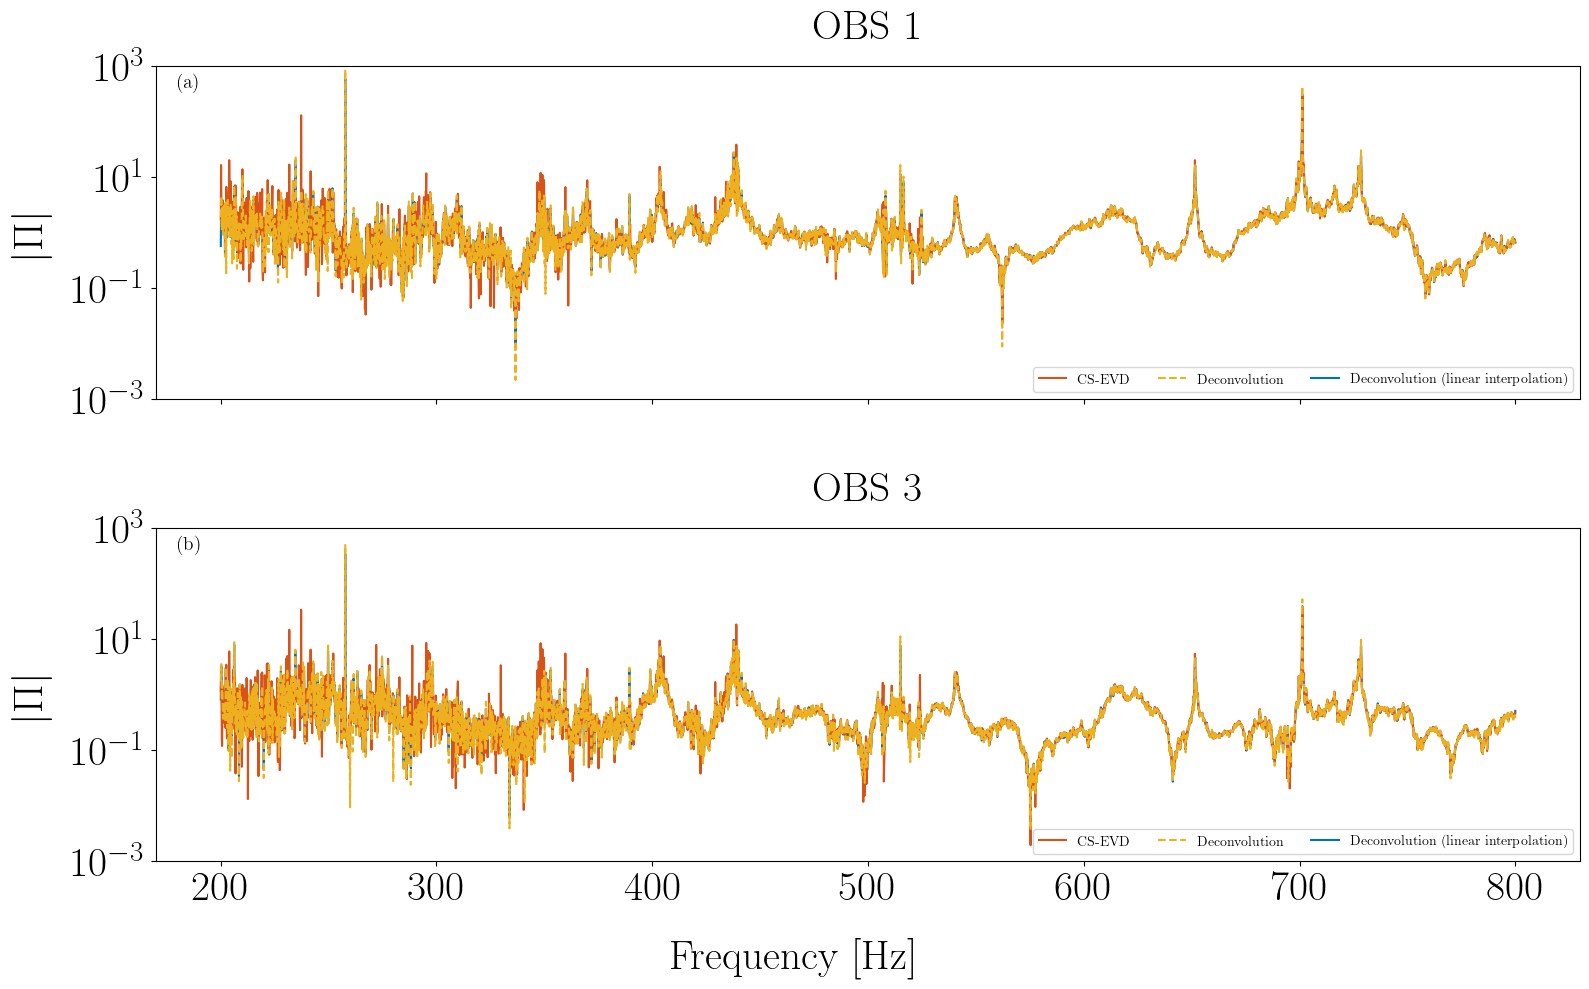

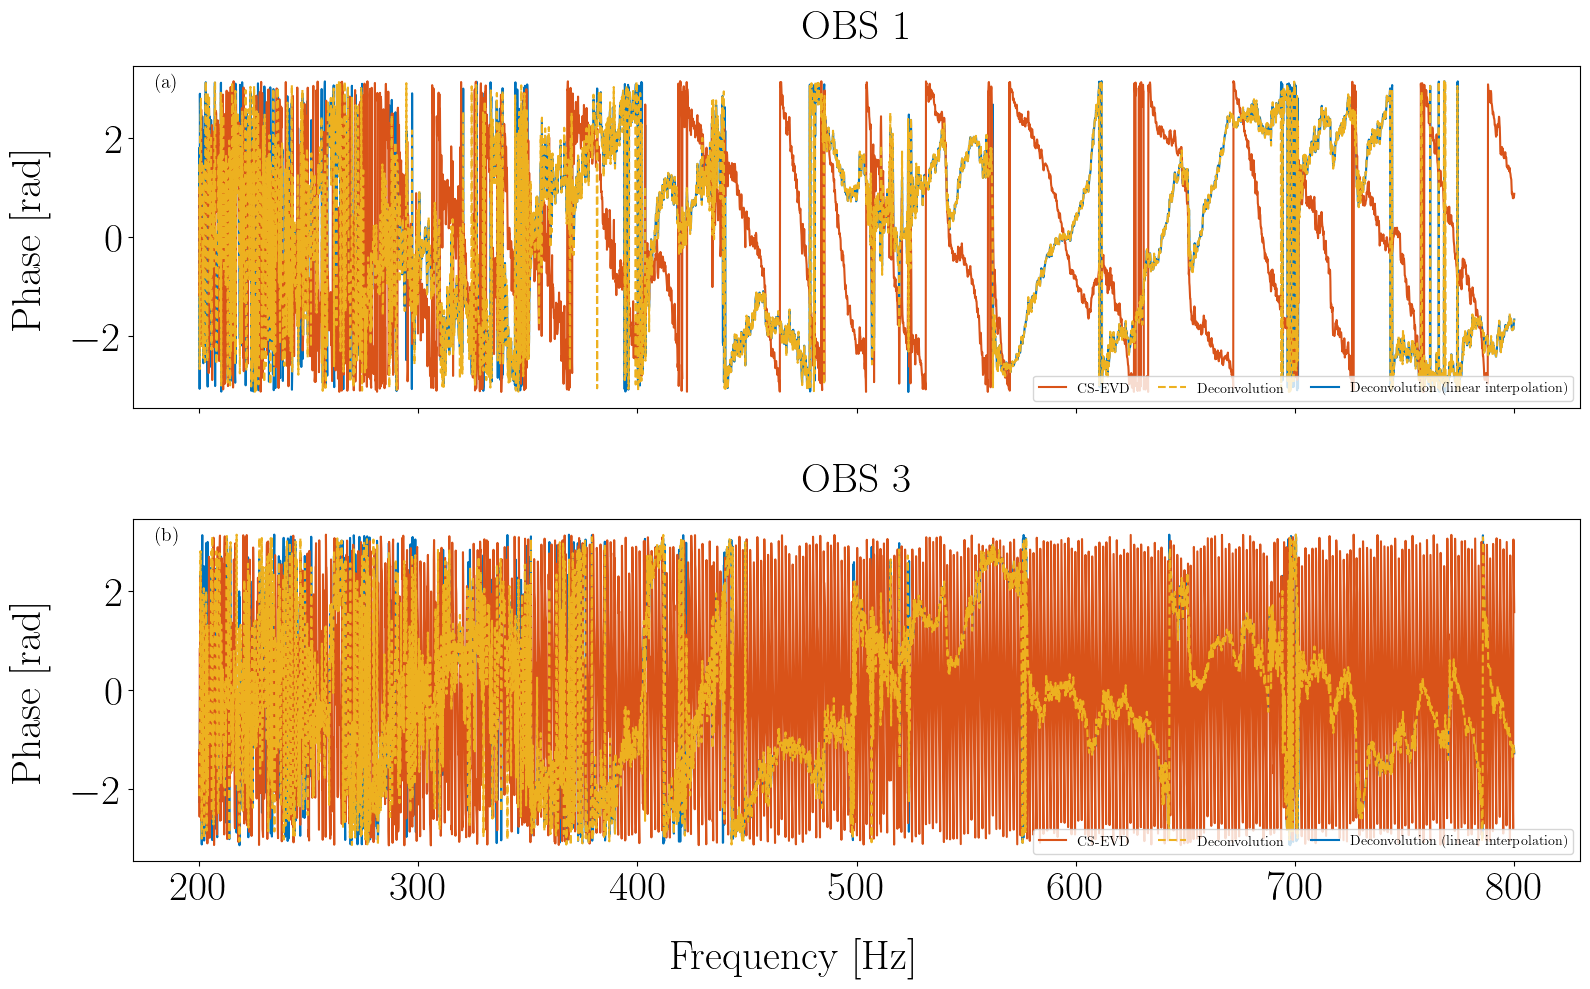

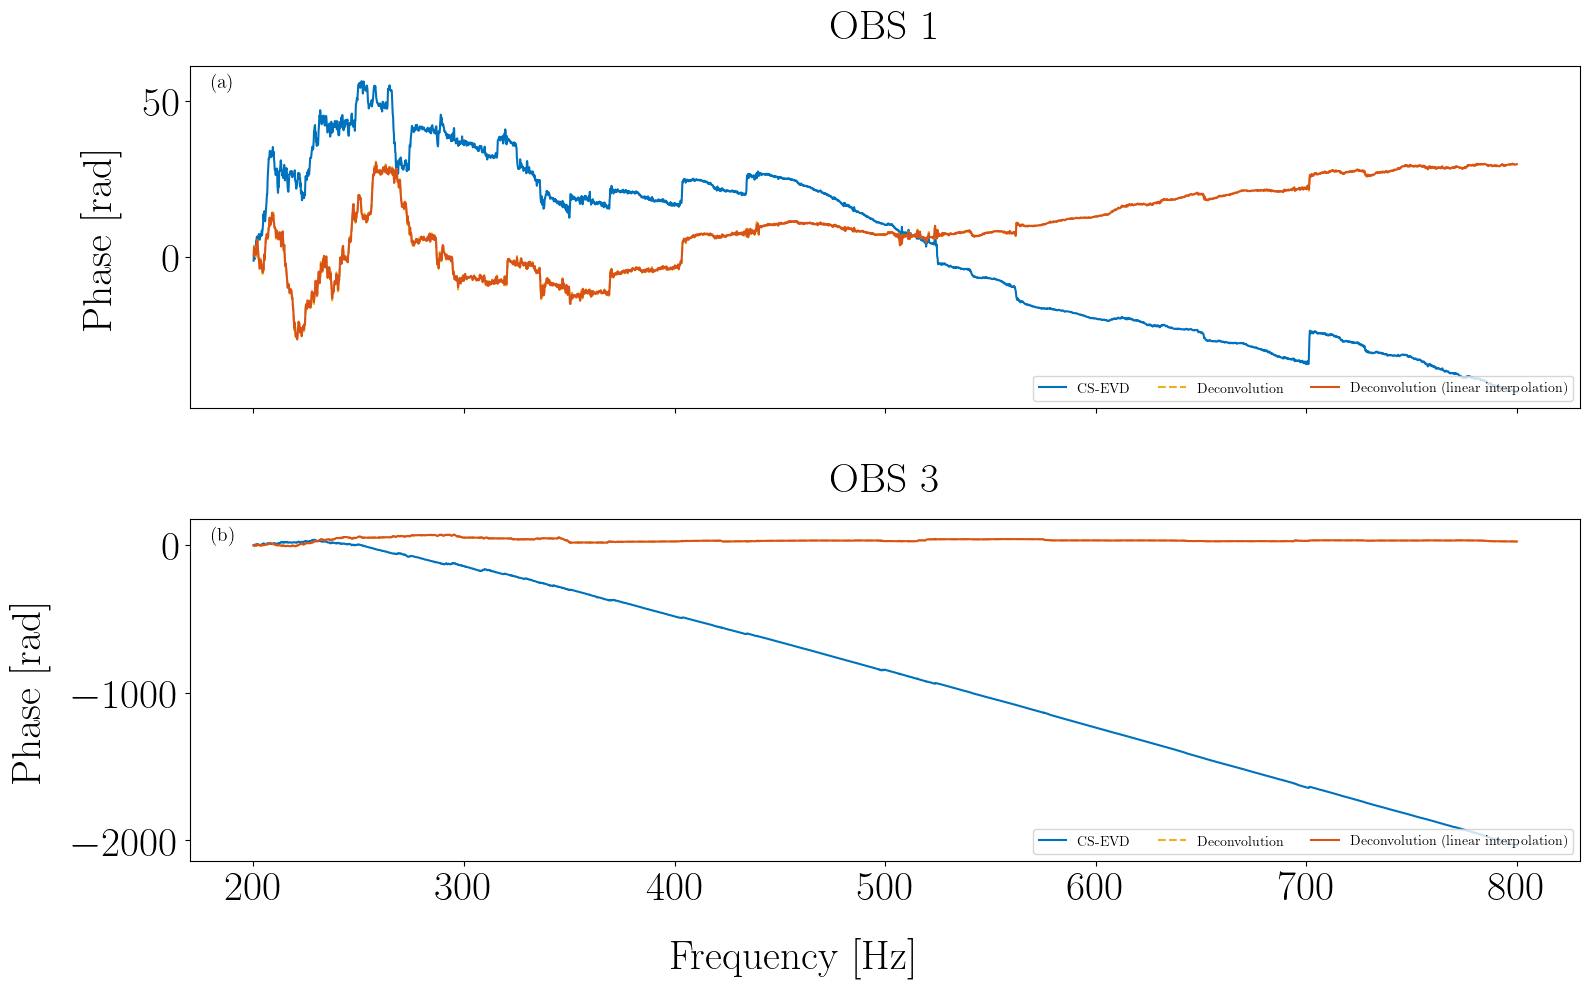

In [33]:
plot_features_ipulse(
    rtf_cs_evd=rtf_cs_evd,
    rtf_deconvolution_interp=rtf_deconvolution_interp,
    freq=f,
    i_pulse=5,
    rtf_deconvolution=rtf_deconvolution,
    freq_deconv=freq_deconv,
)

### Comparison de plusieurs jeux de paramètres 

Params = ((np.int64(8), np.float64(0.95)))
Params = ((np.int64(9), np.float64(0.95)))
Params = ((np.int64(10), np.float64(0.95)))
Params = ((np.int64(11), np.float64(0.95)))
Params = ((np.int64(12), np.float64(0.95)))
Params = ((np.int64(13), np.float64(0.95)))
Params = ((np.int64(14), np.float64(0.95)))


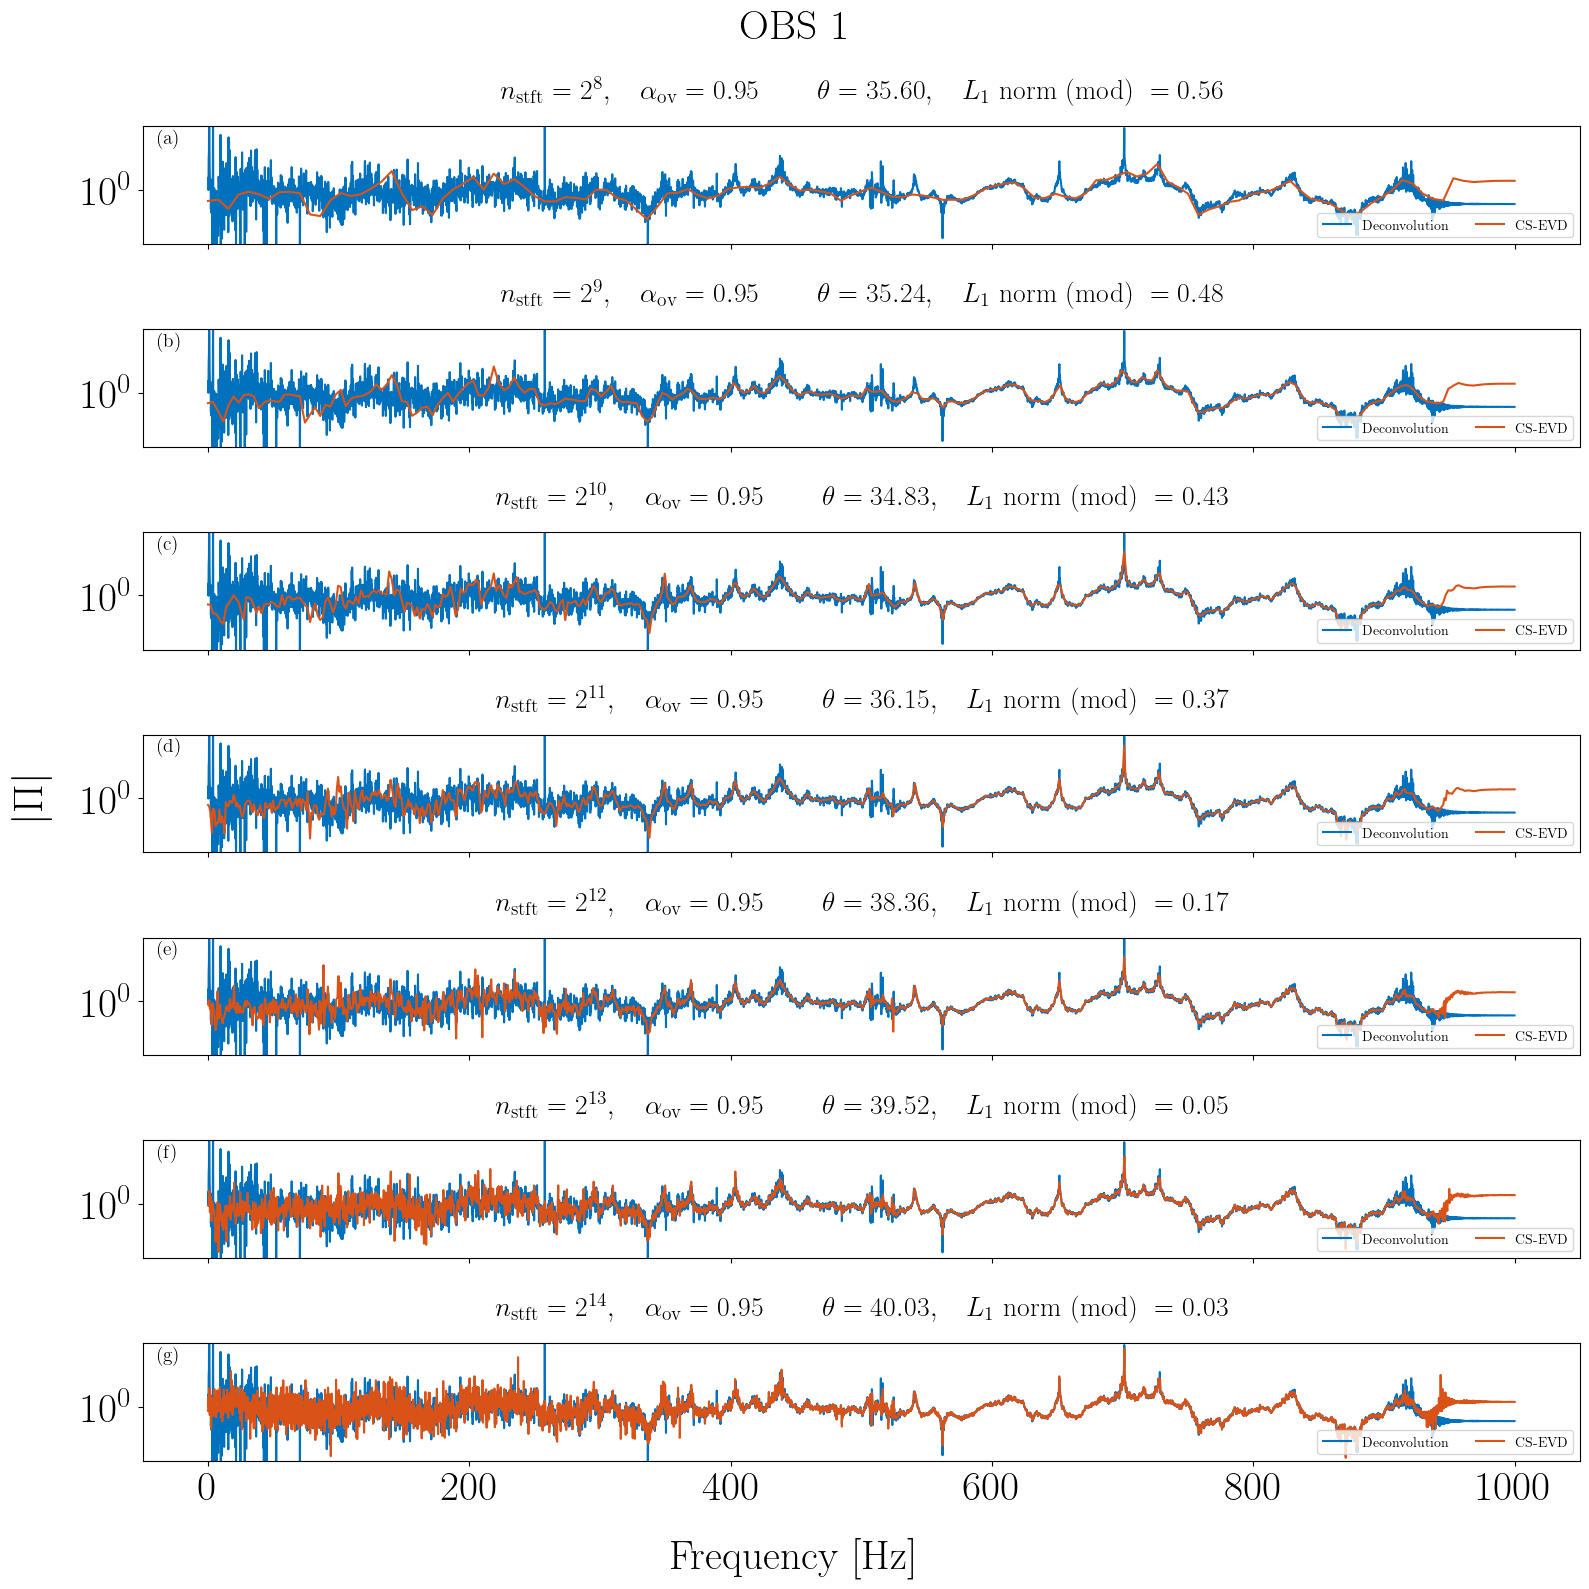

In [34]:
root_path_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library"
i_start = 10
id_start = 501
# library_577.nc

fig, axs = plt.subplots(nrows=len(npersegs_p2), sharex=True, figsize=(16, 16))

id_rcv = 1
id_replica = 5
for i in range(len(npersegs_p2)):
    # print(i)
    i_config = i_start + i * (i_start + 1)
    print(f"Params = ({params[i_config]})")
    id_i = id_start + i_config
    fpath = os.path.join(root_path_data, f"library_{id_i}.nc")
    ds_i = xr.open_dataset(fpath)

    ds_i = ds_i.sel(h_index=id_rcv, replica_id=id_replica)
    ds_i.rtf_amp_deconv.plot(ax=axs[i], label="Deconvolution", color=color(0))
    ds_i.rtf_amp.plot(ax=axs[i], label="CS-EVD", color=color(1))

    axs[i].set_ylim([0.5*1e-2,5*1e2])
    axs[i].set_yscale("log")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    nperseg = params[i_config][0]
    alpha_ov = params[i_config][1]

    ind_nperseg = i
    ind_alpha_ov = i_start
    param_label = (
        r"$n_\text{stft} = 2^{"
        + f"{nperseg}"
        + r"}, \quad \alpha_\text{ov} = "
        + f"{alpha_ov}"
        + r"\quad$"
    )
    distance_label = (
        r"$\quad\theta = "
        + f"{perc_mat_theta[ind_nperseg, ind_alpha_ov]:.2f}°, "
        + r"\quad L_1 \text{ norm (mod) }= "
        + f"{perc_mat_L1_mod[ind_nperseg, ind_alpha_ov]:.2f}"
        + r"$"
    )
    axs[i].set_title(
        param_label + " " + distance_label, 
        fontsize=20,
    )
    axs[i].legend(fontsize=10, ncol=3, loc="lower right")

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.01, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
fig.suptitle(f"OBS {id_rcv}")

fpath = os.path.join(fig_folder, "comparaison_params_obs1.png")
plt.savefig(fpath)

Params = ((np.int64(8), np.float64(0.95)))
Params = ((np.int64(9), np.float64(0.95)))
Params = ((np.int64(10), np.float64(0.95)))
Params = ((np.int64(11), np.float64(0.95)))
Params = ((np.int64(12), np.float64(0.95)))
Params = ((np.int64(13), np.float64(0.95)))
Params = ((np.int64(14), np.float64(0.95)))


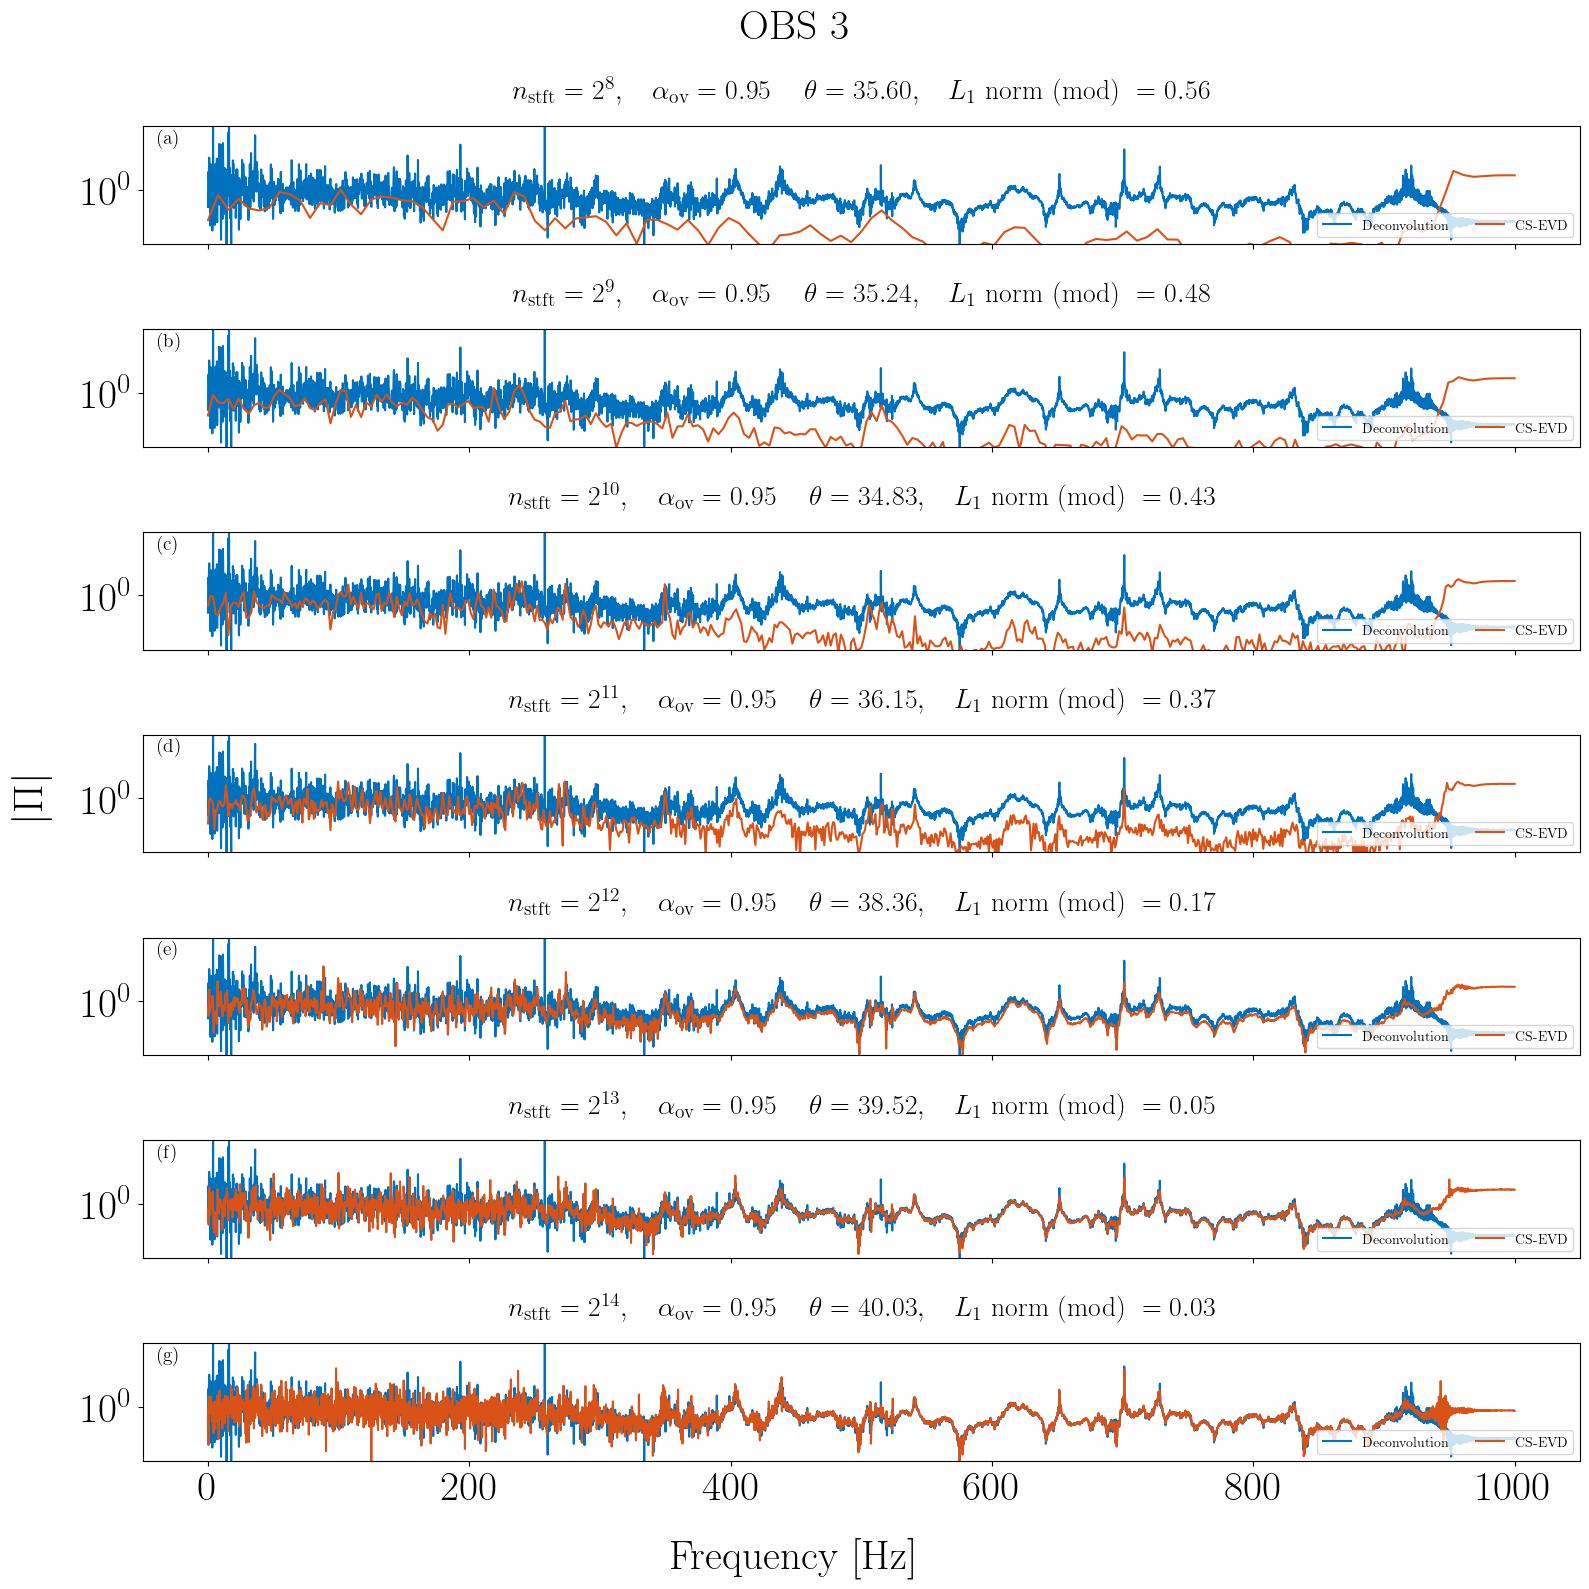

In [35]:
id_rcv = 3
id_replica = 5
fig, axs = plt.subplots(nrows=len(npersegs_p2), sharex=True, figsize=(16, 16))

for i in range(len(npersegs_p2)):
    # print(i)
    i_config = i_start + i * (i_start + 1)
    print(f"Params = ({params[i_config]})")
    id_i = id_start + i_config
    fpath = os.path.join(root_path_data, f"library_{id_i}.nc")
    ds_i = xr.open_dataset(fpath)

    ds_i = ds_i.sel(h_index=id_rcv, replica_id=id_replica)
    ds_i.rtf_amp_deconv.plot(ax=axs[i], label="Deconvolution", color=color(0))
    ds_i.rtf_amp.plot(ax=axs[i], label="CS-EVD", color=color(1))

    axs[i].set_ylim([0.5 * 1e-2, 5 * 1e2])
    axs[i].set_yscale("log")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    nperseg = params[i_config][0]
    alpha_ov = params[i_config][1]

    ind_nperseg = i
    ind_alpha_ov = i_start
    param_label = (
        r"$n_\text{stft} = 2^{"
        + f"{nperseg}"
        + r"}, \quad \alpha_\text{ov} = "
        + f"{alpha_ov}"
        + r"\quad$"
    )
    distance_label = (
        r"$\theta = "
        + f"{perc_mat_theta[ind_nperseg, ind_alpha_ov]:.2f}°, "
        + r"\quad L_1 \text{ norm (mod) }= "
        + f"{perc_mat_L1_mod[ind_nperseg, ind_alpha_ov]:.2f}"
        + r"$"
    )
    axs[i].set_title(
        param_label + " " + distance_label,
        fontsize=20,
    )
    axs[i].legend(fontsize=10, ncol=3, loc="lower right")

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.01, y_pos=0.98, ha="left", va="top"
)
fig.supxlabel("Frequency [Hz]")
fig.supylabel(r"$|\Pi|$")
fig.suptitle(f"OBS {id_rcv}")

fpath = os.path.join(fig_folder, "comparaison_params_obs3.png")
plt.savefig(fpath)